In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


In [3]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("After reshape:", x_train.shape, x_test.shape)


After reshape: (60000, 28, 28, 1) (10000, 28, 28, 1)


In [4]:
model = models.Sequential([

    # 1st Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    # 2nd Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten + Dense Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')   # Output layer
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.8636 - loss: 0.4528 - val_accuracy: 0.9803 - val_loss: 0.0691
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9790 - loss: 0.0659 - val_accuracy: 0.9875 - val_loss: 0.0421
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.9868 - loss: 0.0420 - val_accuracy: 0.9862 - val_loss: 0.0443
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9886 - loss: 0.0334 - val_accuracy: 0.9882 - val_loss: 0.0402
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9926 - loss: 0.0251 - val_accuracy: 0.9908 - val_loss: 0.0345


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test Accuracy:", test_acc)


313/313 - 2s - 8ms/step - accuracy: 0.9879 - loss: 0.0354
Test Accuracy: 0.9879000186920166


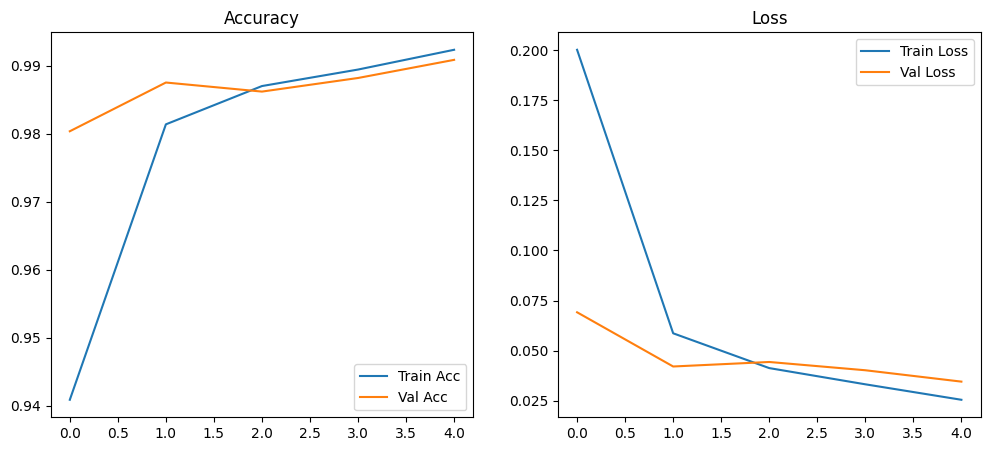

In [8]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.show()


In [9]:
n = 5
for i in range(n):
    img = x_test[i].reshape(1,28,28,1)
    prediction = model.predict(img)
    print("Predicted:", np.argmax(prediction), " | Actual:", y_test[i])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Predicted: 7  | Actual: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted: 2  | Actual: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted: 1  | Actual: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted: 0  | Actual: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted: 4  | Actual: 4


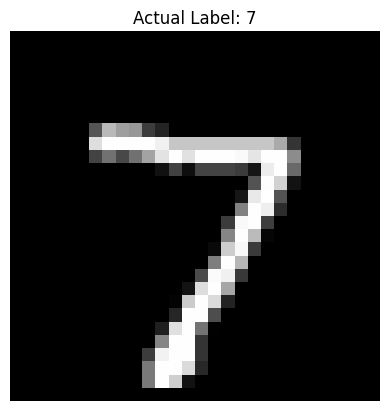

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Label: 7
Actual Label: 7


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Pick any index from test set
index = 0   # change this to view other test images

img = x_test[index]
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

# Make prediction
prediction = model.predict(img.reshape(1,28,28,1))
predicted_label = np.argmax(prediction)

print("Predicted Label:", predicted_label)
print("Actual Label:", y_test[index])
